# Study 3 — Livestream Chat Stitcher & Exploratory Data Analysis
**Trust Behaviors in Collective Chat during Extreme Weather / Tornado Events**

This notebook does two things in sequence:
1. **Part A — Stitcher**: Parses all `.txt` files exported by *YouTube Comment Search (YCS)*, assigns canonical event dates (handles streams crossing midnight), infers creator from filename, and writes a single clean `stitched_chats.csv`.
2. **Part B — EDA**: Reproduces and extends the exploratory analyses from the original notebook, with fixes for known bugs and additional analyses relevant to CSCW/CHI (moderator behavior, audience overlap, comment velocity, user segmentation, sampling strategies).

---
### Expected filename convention
Files should be named so the **creator slug comes first**, separated by a hyphen:
```
twc-6-26-25.txt
ryan-04-02-25_part1.txt
max-march14.txt
```
The creator is extracted as everything before the first `-`. If your files use a different scheme, override via the `CREATOR_OVERRIDES` dict in the config cell.

> **Event date** is always derived from the **first message timestamp** inside the file — never the filename — so streams crossing midnight are grouped correctly.


## Table of Contents
### Part A — Stitcher
- [A1. Mount Drive & Imports](#a1)
- [A2. Configuration](#a2)
- [A3. Parser — Single File](#a3)
- [A4. Stitch All Files](#a4)
- [A5. Event Date Assignment](#a5)
- [A6. Save Stitched CSV](#a6)

### Part B — EDA
- [B1. Load Stitched Data](#b1)
- [B2. Descriptive Statistics](#b2)
- [B3. Temporal Analysis & Comment Velocity](#b3)
- [B4. User Engagement Patterns](#b4)
- [B5. Creator Comparisons](#b5)
- [B6. Moderator / Bot Detection](#b6)
- [B7. Audience Overlap Analysis](#b7)
- [B8. Visualizations](#b8)
- [B9. Sampling Strategies for Manual Coding](#b9)
- [B10. Export Results](#b10)


---
# Part A — Stitcher

In [ ]:
# A1. Mount Drive & Imports
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from collections import Counter
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

print("✓ Libraries imported")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Libraries imported


In [ ]:
# A2. Configuration — edit this cell before running

# ── Folder containing your .txt files ──────────────────────────────────────────
TXT_FOLDER = '/content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/All Individual Chat Files'

# ── Where to save outputs ──────────────────────────────────────────────────────
OUTPUT_FOLDER = '/content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/outputs'

# ── Creator slug overrides ─────────────────────────────────────────────────────
# For any file whose name doesn't match CREATOR_SLUG_MAP below,
# add an entry here: key = full filename stem, value = canonical creator name.
CREATOR_OVERRIDES = {
    # 'some_odd_filename': 'ryan_hall',
}

# ── Canonical creator name mapping ────────────────────────────────────────────
# Maps filename prefix → canonical label used throughout the analysis.
CREATOR_SLUG_MAP = {
    'twc'          : 'twc',
    'texasweather' : 'twc',
    'mv'           : 'max_velocity',
    'max'          : 'max_velocity',
    'max_velocity' : 'max_velocity',
    'maxvelocity'  : 'max_velocity',
    'rh'           : 'ryan_hall',
    'ryan'         : 'ryan_hall',
    'ryan_hall'    : 'ryan_hall',
    'ryanhall'     : 'ryan_hall',
    'ryanhallya'   : 'ryan_hall',
}

# ── Event grouping: max gap (hours) between files to treat as same event ───────
EVENT_GAP_HOURS = 4

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print("✓ Configuration set")
print(f"  TXT folder   : {TXT_FOLDER}")
print(f"  Output folder: {OUTPUT_FOLDER}")
print(f"  Creator map  : {CREATOR_SLUG_MAP}")

✓ Configuration set
  TXT folder   : /content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/All Individual Chat Files
  Output folder: /content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/outputs
  Creator map  : {'twc': 'twc', 'texasweather': 'twc', 'mv': 'max_velocity', 'max': 'max_velocity', 'max_velocity': 'max_velocity', 'maxvelocity': 'max_velocity', 'rh': 'ryan_hall', 'ryan': 'ryan_hall', 'ryan_hall': 'ryan_hall', 'ryanhall': 'ryan_hall', 'ryanhallya': 'ryan_hall'}


In [ ]:
# A3. Parser — single .txt file

def infer_creator(filename_stem: str) -> str:
    """Resolve filename prefix to canonical creator label via CREATOR_SLUG_MAP."""
    if filename_stem in CREATOR_OVERRIDES:
        return CREATOR_OVERRIDES[filename_stem]
    slug = re.split(r'[-_]', filename_stem)[0].lower().strip()
    if slug in CREATOR_SLUG_MAP:
        return CREATOR_SLUG_MAP[slug]
    for key, canonical in CREATOR_SLUG_MAP.items():
        if key in filename_stem.lower():
            return canonical
    print(f"  ⚠  Unrecognised creator prefix '{slug}' in '{filename_stem}' — add to CREATOR_SLUG_MAP")
    return slug


def parse_ycs_file(filepath: str) -> pd.DataFrame:
    """
    Parse a single YCS-exported .txt file into a DataFrame.

    YCS block structure (entries separated by '#####'):
        username (may or may not start with '@')
        youtube.com/channel/... URL
        (blank)
        date: ISO_TIMESTAMP
        (blank)
        (blank)
        comment text (may span multiple lines)
        (blank)
    """
    path = Path(filepath)
    creator = infer_creator(path.stem)

    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        raw = f.read()

    # ── Extract file-level metadata ──────────────────────────────────────────
    video_url = ''
    title = ''
    url_match = re.search(r'Video URL:\s*(https?://\S+)', raw)
    title_match = re.search(r'Title:\s*(.+)', raw)
    if url_match:
        video_url = url_match.group(1).strip()
    if title_match:
        title = title_match.group(1).strip()

    # ── Split into blocks ────────────────────────────────────────────────────
    blocks = raw.split('#####')

    records = []
    for block in blocks:
        block = block.strip()
        if not block:
            continue

        lines = [l.strip() for l in block.splitlines()]

        # ── Find channel URL as anchor ───────────────────────────────────────
        # More reliable than '@' since many display names have no '@' prefix
        channel_url_idx = None
        channel_url = ''
        for i, line in enumerate(lines):
            if line.startswith('youtube.com/channel/') or line.startswith('http'):
                channel_url_idx = i
                channel_url = line
                break

        if channel_url_idx is None:
            continue  # header block or empty — skip

        # ── Username: non-empty line immediately before channel URL ──────────
        username = None
        username_idx = None
        for i in range(channel_url_idx - 1, -1, -1):
            if lines[i].strip():
                username = lines[i].strip()
                username_idx = i
                break

        if username is None:
            continue

        # ── Timestamp ────────────────────────────────────────────────────────
        timestamp_str = None
        for line in lines:
            if line.startswith('date:'):
                timestamp_str = line.replace('date:', '').strip()
                break

        if not timestamp_str:
            continue  # malformed block

        # ── Comment text: everything after the date line ─────────────────────
        date_idx = None
        for i, line in enumerate(lines):
            if line.startswith('date:'):
                date_idx = i
                break

        if date_idx is not None:
            text_lines = lines[date_idx + 1:]
            while text_lines and text_lines[0] == '':
                text_lines = text_lines[1:]
            while text_lines and text_lines[-1] == '':
                text_lines = text_lines[:-1]
            comment_text = ' '.join(text_lines).strip()
        else:
            comment_text = ''

        records.append({
            'creator'          : creator,
            'source_file'      : path.name,
            'video_url'        : video_url,
            'video_title'      : title,
            'username'         : username,
            'channel_url'      : channel_url,
            'comment_timestamp': timestamp_str,
            'comment_text'     : comment_text,
        })

    df = pd.DataFrame(records)
    if df.empty:
        print(f'  ⚠  No records parsed from {path.name}')
        return df

    df['comment_datetime'] = (
        pd.to_datetime(df['comment_timestamp'], errors='coerce', utc=True)
        .dt.tz_convert('America/Chicago')
        .dt.tz_localize(None)
    )
    df['word_count'] = df['comment_text'].apply(
        lambda x: len(str(x).split()) if pd.notna(x) else 0
    )
    return df


print('✓ Parser defined')

✓ Parser defined


In [ ]:
# A4. Stitch All Files

def stitch_all_files(folder: str, pattern: str = '.txt') -> pd.DataFrame:
    """
    Find all .txt files in `folder` using os.walk (handles special characters
    in folder names like ** and [brackets]), parse each one, and concatenate
    into a single DataFrame sorted chronologically.
    """
    files = []
    for root, dirs, filenames in os.walk(folder):
        for fname in filenames:
            if fname.endswith(pattern):
                files.append(os.path.join(root, fname))
    files = sorted(files)

    print(f"Found {len(files)} .txt file(s) in {folder}")
    if not files:
        raise FileNotFoundError(f"No .txt files found in {folder}. Check TXT_FOLDER in config.")

    frames = []
    for fp in files:
        fname = Path(fp).name
        print(f"  Parsing {fname} ...", end=' ')
        try:
            df_file = parse_ycs_file(fp)
            n = len(df_file)
            print(f"{n:,} rows")
            if n > 0:
                frames.append(df_file)
        except Exception as e:
            print(f"ERROR: {e}")

    if not frames:
        raise ValueError("No data was successfully parsed.")

    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values('comment_datetime').reset_index(drop=True)
    print(f"\n✓ Stitched {len(df):,} total rows from {len(frames)} file(s)")
    return df


df_raw = stitch_all_files(TXT_FOLDER)
print(f"Date range: {df_raw['comment_datetime'].min()} → {df_raw['comment_datetime'].max()}")

Found 36 .txt file(s) in /content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/All Individual Chat Files
  Parsing max_velocity-3-14-25.txt ... 56,789 rows
  Parsing max_velocity-3-15-25-2.txt ... 23,678 rows
  Parsing max_velocity-3-15-25.txt ... 41,952 rows
  Parsing max_velocity-4-2-25-2.txt ... 67,863 rows
  Parsing max_velocity-4-2-25.txt ... 16,177 rows
  Parsing max_velocity-4-3-25.txt ... 18,499 rows
  Parsing max_velocity-4-4-25.txt ... 34,065 rows
  Parsing max_velocity-4-5-25.txt ... 34,647 rows
  Parsing max_velocity-5-15-25.txt ... 32,039 rows
  Parsing max_velocity-5-16-25.txt ... 40,641 rows
  Parsing max_velocity-5-17-25.txt ... 8,218 rows
  Parsing max_velocity-5-18-25.txt ... 44,690 rows
  Parsing max_velocity-5-19-25.txt ... 44,964 rows
  Parsing max_velocity-5-20-25.txt ... 35,870 rows
  Parsing max_velocity-6-20-25.txt ... 20,551 rows
  Parsing ryan_hall-

In [ ]:
# A5. Event Date Assignment
#
# Problem: a single tornadic event may span multiple source files AND cross midnight.
# A message sent at 00:05 on April 3rd is still part of the April 2nd event if the
# stream started on April 2nd.
#
# Strategy:
#   1. For each source file, find the earliest message timestamp → that is the
#      file's 'stream_start'.
#   2. Assign ALL messages in that file event_date = stream_start.date()
#   3. Then, within each creator, merge files whose stream windows overlap or
#      whose gap is ≤ EVENT_GAP_HOURS. The merged group takes the earliest date.

def assign_event_dates(df: pd.DataFrame, gap_hours: float = EVENT_GAP_HOURS) -> pd.DataFrame:
    df = df.copy()

    # Step 1: file-level stream_start
    file_starts = (
        df.groupby(['creator', 'source_file'])['comment_datetime']
        .min()
        .reset_index()
        .rename(columns={'comment_datetime': 'stream_start'})
    )
    file_ends = (
        df.groupby(['creator', 'source_file'])['comment_datetime']
        .max()
        .reset_index()
        .rename(columns={'comment_datetime': 'stream_end'})
    )
    file_meta = file_starts.merge(file_ends, on=['creator', 'source_file'])
    file_meta = file_meta.sort_values(['creator', 'stream_start']).reset_index(drop=True)

    # Step 2: group files into events (per creator)
    gap = pd.Timedelta(hours=gap_hours)
    event_ids = []
    for creator, grp in file_meta.groupby('creator'):
        grp = grp.sort_values('stream_start').reset_index(drop=True)
        current_event_start = grp.loc[0, 'stream_start']
        current_event_end   = grp.loc[0, 'stream_end']
        event_date          = current_event_start.date()
        for idx, row in grp.iterrows():
            if row['stream_start'] - current_event_end > gap:
                # New event: reset
                current_event_start = row['stream_start']
                event_date          = current_event_start.date()
            current_event_end = max(current_event_end, row['stream_end'])
            event_ids.append({
                'creator'    : creator,
                'source_file': row['source_file'],
                'event_date' : pd.Timestamp(event_date)
            })

    event_map = pd.DataFrame(event_ids)

    # Step 3: merge back
    df = df.merge(event_map, on=['creator', 'source_file'], how='left')

    return df


df_raw = assign_event_dates(df_raw)

# Preview event assignment
event_summary = (
    df_raw.groupby(['creator', 'event_date'])
    .agg(
        n_comments=('comment_text', 'count'),
        n_files=('source_file', 'nunique'),
        stream_start=('comment_datetime', 'min'),
        stream_end=('comment_datetime', 'max')
    )
    .reset_index()
)
event_summary['duration_hrs'] = (
    (event_summary['stream_end'] - event_summary['stream_start'])
    .dt.total_seconds() / 3600
).round(1)

print("Event assignment preview:")
print(event_summary.sort_values('n_comments', ascending=False).to_string(index=False))

Event assignment preview:
     creator event_date  n_comments  n_files        stream_start          stream_end  duration_hrs
max_velocity 2025-03-14      122419        3 2025-03-14 13:46:27 2025-03-16 01:10:43          35.4
   ryan_hall 2025-04-02      101380        2 2025-04-02 11:01:15 2025-04-03 03:09:14          16.1
max_velocity 2025-04-02       84040        2 2025-04-02 07:38:53 2025-04-03 01:21:10          17.7
max_velocity 2025-05-14       72680        2 2025-05-14 23:53:06 2025-05-17 00:11:47          48.3
   ryan_hall 2025-05-16       60995        1 2025-05-16 12:00:00 2025-05-16 23:56:34          11.9
   ryan_hall 2025-05-20       55514        1 2025-05-20 13:37:57 2025-05-20 23:48:52          10.2
   ryan_hall 2025-05-19       53256        1 2025-05-19 13:56:04 2025-05-20 00:22:08          10.4
   ryan_hall 2025-03-14       52392        1 2025-03-14 14:33:48 2025-03-15 02:03:26          11.5
   ryan_hall 2025-04-05       46601        1 2025-04-05 11:45:57 2025-04-06 00:02:4

In [ ]:
# A6. Final preprocessing & Save

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Temporal features
    df['hour']        = df['comment_datetime'].dt.hour
    df['day_of_week'] = df['comment_datetime'].dt.day_name()
    df['date']        = df['comment_datetime'].dt.date

    # Minutes since event start (per creator-event combination)
    df['time_from_event_start'] = df.groupby(
        ['creator', 'event_date']
    )['comment_datetime'].transform(
        lambda x: (x - x.min()).dt.total_seconds() / 60
    )

    # Clean username (strip leading @)
    df['username_clean'] = df['username'].str.lstrip('@')

    # Comment length category
    df['length_category'] = pd.cut(
        df['word_count'],
        bins=[0, 1, 5, 15, float('inf')],
        labels=['Very short (1w)', 'Short (2-5w)', 'Medium (6-15w)', 'Long (16+w)'],
        include_lowest=True
    )

    # NOTE: No bot flagging at stitch time.
    # Automated / moderator accounts are identified later in B6
    # based on observed comment patterns and frequency.

    return df


df = preprocess(df_raw)

out_path = os.path.join(OUTPUT_FOLDER, 'stitched_chats.csv')
df.to_csv(out_path, index=False)
print(f'✓ Saved stitched CSV: {out_path}')
print(f'  Rows    : {len(df):,}')
print(f'  Columns : {list(df.columns)}')
print(f'  Creators: {sorted(df["creator"].unique())}')

✓ Saved stitched CSV: /content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/outputs/stitched_chats.csv
  Rows    : 1,116,371
  Columns : ['creator', 'source_file', 'video_url', 'video_title', 'username', 'channel_url', 'comment_timestamp', 'comment_text', 'comment_datetime', 'word_count', 'event_date', 'hour', 'day_of_week', 'date', 'time_from_event_start', 'username_clean', 'length_category']
  Creators: ['max_velocity', 'ryan_hall', 'twc']


---
# Part B — Exploratory Data Analysis

If you already have a stitched CSV from a previous run, you can skip Part A and load it directly in **B1**.

In [ ]:
# B1. Load Stitched Data
# ─────────────────────────────────────────────────────────────────────────────
# If running Part B independently (skip Part A), set the path below and
# uncomment the two lines.
#
# STITCHED_CSV = '/content/drive/MyDrive/.../outputs/stitched_chats.csv'
# df = pd.read_csv(STITCHED_CSV, parse_dates=['comment_datetime', 'event_date'])
# df = preprocess(df)  # re-apply if needed

# If running sequentially after Part A, df is already in memory.
# Just confirm it looks right:
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Creators: {df['creator'].unique()}")
print(f"Events: {df['event_date'].nunique()}")
df.head(3)

Rows: 1,116,371
Columns: ['creator', 'source_file', 'video_url', 'video_title', 'username', 'channel_url', 'comment_timestamp', 'comment_text', 'comment_datetime', 'word_count', 'event_date', 'hour', 'day_of_week', 'date', 'time_from_event_start', 'username_clean', 'length_category']
Creators: ['max_velocity' 'ryan_hall' 'twc']
Events: 16


,creator,source_file,video_url,video_title,username,channel_url,comment_timestamp,comment_text,comment_datetime,word_count,event_date,hour,day_of_week,date,time_from_event_start,username_clean,length_category
0,max_velocity,max_velocity-3-14-25.txt,https://www.youtube.com/watch?v=YYOlHQR0RDU,"(412) The Insane Pi Day Tornado Outbreak, As It Occurred Live - 3/14/2025 - YouTube",Max Velocity - Severe Weather Center,youtube.com/channel/UCvBVK2ymNzPLRJrgip2GeQQ,2025-03-14T18:46:27,1 MILLION SUBSCRIBER MERCH - http://shopmaxvelocity.net/,2025-03-14 13:46:27,6,2025-03-14,13,Friday,2025-03-14,0.000000,Max Velocity - Severe Weather Center,Medium (6-15w)
1,max_velocity,max_velocity-3-14-25.txt,https://www.youtube.com/watch?v=YYOlHQR0RDU,"(412) The Insane Pi Day Tornado Outbreak, As It Occurred Live - 3/14/2025 - YouTube",TheEASguy,youtube.com/channel/UCvWgOMkZa_bXYV2TWiPz0kw,2025-03-14T19:04:54,It’s not a wind driven high risk,2025-03-14 14:04:54,7,2025-03-14,14,Friday,2025-03-14,18.450000,TheEASguy,Medium (6-15w)
2,max_velocity,max_velocity-3-14-25.txt,https://www.youtube.com/watch?v=YYOlHQR0RDU,"(412) The Insane Pi Day Tornado Outbreak, As It Occurred Live - 3/14/2025 - YouTube",Zack Venzon,youtube.com/channel/UCDOylYGEBL5NKSFd-qxWHcw,2025-03-14T19:04:55,only the 4th time a day 2 risk has ever been issued,2025-03-14 14:04:55,12,2025-03-14,14,Friday,2025-03-14,18.466667,Zack Venzon,Medium (6-15w)


In [ ]:
# B2. Descriptive Statistics
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nTotal comments     : {len(df):,}")
print(f"Unique users       : {df['username_clean'].nunique():,}")
print(f"Creators           : {df['creator'].nunique()} — {sorted(df['creator'].unique())}")
print(f"Event dates        : {df['event_date'].nunique()}")
print(f"Source files       : {df['source_file'].nunique()}")
print(f"Date range         : {df['comment_datetime'].min()} → {df['comment_datetime'].max()}")


print("\n" + "=" * 80)
print("COMMENT LENGTH DISTRIBUTION")
print("=" * 80)
# Human comments only (excluding bots) for meaningful stats
# Bot flagging happens later in B6 after manual review.
# For now dfh = full dataset.
dfh = df.copy()
print(f"\nWord count (human comments, n={len(dfh):,}):")
print(dfh['word_count'].describe().round(2))
print()
for label, cond in [
    ('Empty (0 words)',  dfh['word_count'] == 0),
    ('Very short (1w)', dfh['word_count'] == 1),
    ('Short (2-5w)',     (dfh['word_count'] >= 2) & (dfh['word_count'] <= 5)),
    ('Medium (6-15w)',   (dfh['word_count'] >= 6) & (dfh['word_count'] <= 15)),
    ('Long (16+w)',      dfh['word_count'] >= 16),
]:
    n = cond.sum()
    print(f"  {label:<22}: {n:>8,}  ({n/len(dfh)*100:.1f}%)")

print("\n" + "=" * 80)
print("CREATOR SUMMARY")
print("=" * 80)
creator_summary = pd.DataFrame({
    'Total Comments'    : df.groupby('creator').size(),
    'Human Comments'    : dfh.groupby('creator').size(),
    'Unique Users'      : df.groupby('creator')['username_clean'].nunique(),
    'Events Covered'    : df.groupby('creator')['event_date'].nunique(),
    'Avg Comments/Event': (df.groupby('creator').size() / df.groupby('creator')['event_date'].nunique()).round(0),
    'Avg Word Count'    : dfh.groupby('creator')['word_count'].mean().round(2),
    'Median Word Count' : dfh.groupby('creator')['word_count'].median(),
    '% Short (≤2w)'     : (dfh[dfh['word_count'] <= 2].groupby('creator').size() / dfh.groupby('creator').size() * 100).round(1),
    '% Long (10+w)'     : (dfh[dfh['word_count'] >= 10].groupby('creator').size() / dfh.groupby('creator').size() * 100).round(1),
})
print(creator_summary.sort_values('Total Comments', ascending=False))

print("\n" + "=" * 80)
print("EVENT SUMMARY")
print("=" * 80)
print(event_summary.sort_values('n_comments', ascending=False).to_string(index=False))

DATASET OVERVIEW

Total comments     : 1,116,371
Unique users       : 217,514
Creators           : 3 — ['max_velocity', 'ryan_hall', 'twc']
Event dates        : 16
Source files       : 36
Date range         : 2025-03-14 13:46:27 → 2025-06-21 02:44:15

COMMENT LENGTH DISTRIBUTION

Word count (human comments, n=1,116,371):
count    1116371.00
mean           7.43
std            6.44
min            0.00
25%            3.00
50%            6.00
75%           10.00
max           74.00
Name: word_count, dtype: float64

  Empty (0 words)       :    1,084  (0.1%)
  Very short (1w)       :  123,370  (11.1%)
  Short (2-5w)          :  416,474  (37.3%)
  Medium (6-15w)        :  462,646  (41.4%)
  Long (16+w)           :  112,797  (10.1%)

CREATOR SUMMARY
              Total Comments  Human Comments  Unique Users  Events Covered  \
creator                                                                      
ryan_hall             579382          579382        148368              12   
max_velocity 

In [ ]:
# B3. Temporal Analysis & Comment Velocity
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 80)
print("TEMPORAL PATTERNS (human comments only)")
print("=" * 80)

# Comments by hour of day
hourly = dfh.groupby('hour').size().sort_index()
print(f"\nPeak hour : {hourly.idxmax()}:00 ({hourly.max():,} comments)")
print(f"Quiet hour: {hourly.idxmin()}:00 ({hourly.min():,} comments)")
print("\nComments by hour:")
print(hourly.to_string())

# Comments by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly = dfh.groupby('day_of_week').size().reindex(day_order)
print("\nComments by day of week:")
print(weekly.to_string())

print("\n" + "=" * 80)
print("COMMENT VELOCITY — top events (5-minute bins)")
print("=" * 80)

top_events = event_summary.nlargest(5, 'n_comments')[['creator', 'event_date']]
for _, row in top_events.iterrows():
    subset = dfh[
        (dfh['creator'] == row['creator']) &
        (dfh['event_date'] == row['event_date'])
    ]
    max_t = subset['time_from_event_start'].max()
    bins = pd.cut(
        subset['time_from_event_start'],
        bins=np.arange(0, max_t + 5, 5),
        right=False
    )
    vel = subset.groupby(bins, observed=False).size()
    n_bins = len(vel)
    print(f"\n  {row['creator'].upper()} — {row['event_date'].date()}:")
    print(f"    Duration         : {max_t/60:.1f} hrs ({max_t:.0f} min)")
    print(f"    Total comments   : {len(subset):,}")
    print(f"    Peak 5-min burst : {vel.max():,} comments")
    print(f"    Avg / 5-min      : {vel.mean():.0f} comments")
    print(f"    Peak at minute   : {vel.idxmax().left:.0f}")

TEMPORAL PATTERNS (human comments only)

Peak hour : 21:00 (103,902 comments)
Quiet hour: 3:00 (1,136 comments)

Comments by hour:
hour
0      56346
1      23937
2       8331
3       1136
7       1332
8       3759
9       4811
10     11667
11      9637
12     26324
13     33392
14     80798
15     87741
16     89092
17     85127
18    101666
19     97840
20     98814
21    103902
22    101642
23     89077

Comments by day of week:
day_of_week
Monday       109181
Tuesday       96821
Wednesday    157836
Thursday     147679
Friday       283897
Saturday     223041
Sunday        97916

COMMENT VELOCITY — top events (5-minute bins)

  MAX_VELOCITY — 2025-03-14:
    Duration         : 35.4 hrs (2124 min)
    Total comments   : 122,419
    Peak 5-min burst : 1,383 comments
    Avg / 5-min      : 288 comments
    Peak at minute   : 2070

  RYAN_HALL — 2025-04-02:
    Duration         : 16.1 hrs (968 min)
    Total comments   : 101,380
    Peak 5-min burst : 1,602 comments
    Avg / 5-min      :

In [ ]:
# B4. User Engagement Patterns
# ─────────────────────────────────────────────────────────────────────────────

# Build user profiles (human only)
user_comment_counts = dfh.groupby('username_clean').size().sort_values(ascending=False)

user_profiles = pd.DataFrame({
    'total_comments'   : dfh.groupby('username_clean').size(),
    'avg_word_count'   : dfh.groupby('username_clean')['word_count'].mean().round(2),
    'median_word_count': dfh.groupby('username_clean')['word_count'].median(),
    'num_events'       : dfh.groupby('username_clean')['event_date'].nunique(),
    'num_creators'     : dfh.groupby('username_clean')['creator'].nunique(),
    'first_seen'       : dfh.groupby('username_clean')['comment_datetime'].min(),
    'last_seen'        : dfh.groupby('username_clean')['comment_datetime'].max(),
})
user_profiles['days_active'] = (
    (user_profiles['last_seen'] - user_profiles['first_seen']).dt.days + 1
)
user_profiles['comments_per_event'] = (
    user_profiles['total_comments'] / user_profiles['num_events']
).round(2)

def segment_user(row):
    if row['total_comments'] == 1:
        return 'One-time'
    elif row['total_comments'] >= 100:
        return 'Power User'
    elif row['num_events'] >= 6:
        return 'Regular'
    elif row['num_events'] == 1:
        return 'Single Event'
    else:
        return 'Casual'

user_profiles['segment'] = user_profiles.apply(segment_user, axis=1)

print("=" * 80)
print("USER ENGAGEMENT")
print("=" * 80)
print(f"\nTotal unique users (human): {len(user_profiles):,}")
print()
for label, cond in [
    ('Single comment',      user_comment_counts == 1),
    ('2–5 comments',        (user_comment_counts >= 2)  & (user_comment_counts <= 5)),
    ('6–20 comments',       (user_comment_counts >= 6)  & (user_comment_counts <= 20)),
    ('21–100 comments',     (user_comment_counts >= 21) & (user_comment_counts <= 100)),
    ('100+ comments',       user_comment_counts >= 100),
]:
    n = cond.sum()
    print(f"  {label:<22}: {n:>8,}  ({n/len(user_comment_counts)*100:.1f}%)")

print("\nUser segments:")
seg_counts = user_profiles['segment'].value_counts()
seg_pct    = (seg_counts / len(user_profiles) * 100).round(2)
for seg in seg_counts.index:
    print(f"  {seg:<15}: {seg_counts[seg]:>7,}  ({seg_pct[seg]:.1f}%)")

print("\nSegment characteristics:")
seg_stats = user_profiles.groupby('segment').agg(
    mean_comments=('total_comments', 'mean'),
    median_comments=('total_comments', 'median'),
    mean_events=('num_events', 'mean'),
    mean_word_count=('avg_word_count', 'mean'),
    n_users=('total_comments', 'count')
).round(2)
print(seg_stats)

print("\nTop 20 most active users:")
for rank, (uname, cnt) in enumerate(user_comment_counts.head(20).items(), 1):
    print(f"  {rank:2d}. {uname[:40]:<40} {cnt:>6,} comments")

print("\nEvent participation:")
user_event_counts = user_profiles['num_events']
for label, cond in [
    ('Single event',   user_event_counts == 1),
    ('2–3 events',     (user_event_counts >= 2) & (user_event_counts <= 3)),
    ('4–5 events',     (user_event_counts >= 4) & (user_event_counts <= 5)),
    ('6+ events',      user_event_counts >= 6),
]:
    n = cond.sum()
    print(f"  {label:<15}: {n:>8,}  ({n/len(user_profiles)*100:.1f}%)")

print("\nTop 10 most event-loyal users:")
top_loyal = user_profiles.sort_values(
    ['num_events', 'total_comments'], ascending=[False, False]
).head(10)
for rank, (uname, row) in enumerate(top_loyal.iterrows(), 1):
    print(f"  {rank:2d}. {uname[:30]:<30} {row['num_events']:2.0f} events  {row['total_comments']:5.0f} comments")

USER ENGAGEMENT

Total unique users (human): 217,514

  Single comment        :   93,900  (43.2%)
  2–5 comments          :   83,340  (38.3%)
  6–20 comments         :   32,201  (14.8%)
  21–100 comments       :    7,351  (3.4%)
  100+ comments         :      732  (0.3%)

User segments:
  One-time       :  93,900  (43.2%)
  Casual         :  68,088  (31.3%)
  Single Event   :  48,439  (22.3%)
  Regular        :   6,355  (2.9%)
  Power User     :     732  (0.3%)

Segment characteristics:
              mean_comments  median_comments  mean_events  mean_word_count  \
segment                                                                      
Casual                 6.84              4.0         2.68             7.62   
One-time               1.00              1.0         1.00             7.74   
Power User           248.06            151.5         8.83             6.77   
Regular               30.07             23.0         7.28             7.25   
Single Event           3.80             

In [ ]:
# B5. Creator Comparisons
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 80)
print("CREATOR COMPARISON")
print("=" * 80)
print(creator_summary.sort_values('Total Comments', ascending=False))

print("\n" + "=" * 80)
print("USER LOYALTY BY CREATOR")
print("=" * 80)
for creator, grp in dfh.groupby('creator'):
    creator_users = grp.groupby('username_clean').size()
    n = len(creator_users)
    print(f"\n{creator.upper()} (n users = {n:,}):")
    for label, cond in [
        ('One-time',     creator_users == 1),
        ('Repeat (5+)',  creator_users >= 5),
        ('Super (50+)',  creator_users >= 50),
    ]:
        cnt = cond.sum()
        print(f"  {label:<15}: {cnt:>6,}  ({cnt/n*100:.1f}%)")
    print(f"  Most active user : {creator_users.max()} comments ({creator_users.idxmax()})")

print("\n" + "=" * 80)
print("CROSS-CREATOR PARTICIPATION")
print("=" * 80)
ucreator = dfh.groupby('username_clean')['creator'].nunique()
for n_c in sorted(dfh['creator'].nunique() + 1 - np.arange(1, dfh['creator'].nunique() + 1)):
    cnt = (ucreator == n_c).sum()
    label = f"{n_c} creator{'s' if n_c > 1 else ''}"
    print(f"  {label:<20}: {cnt:>8,}  ({cnt/len(ucreator)*100:.1f}%)")

print("\n" + "=" * 80)
print("SHARED AUDIENCE ANALYSIS")
print("=" * 80)
creators = sorted(dfh['creator'].unique())
audience = {c: set(dfh[dfh['creator'] == c]['username_clean'].unique()) for c in creators}
for i, c1 in enumerate(creators):
    for c2 in creators[i + 1:]:
        shared   = audience[c1] & audience[c2]
        only_c1  = audience[c1] - audience[c2]
        only_c2  = audience[c2] - audience[c1]
        pct_c1   = len(shared) / len(audience[c1]) * 100
        pct_c2   = len(shared) / len(audience[c2]) * 100
        print(f"\n{c1.upper()} ↔ {c2.upper()}:")
        print(f"  Shared users: {len(shared):,}  ({pct_c1:.1f}% of {c1}, {pct_c2:.1f}% of {c2})")
        print(f"  {c1.upper()} exclusive: {len(only_c1):,}")
        print(f"  {c2.upper()} exclusive: {len(only_c2):,}")

# Jaccard similarity matrix
print("\nJaccard Similarity Matrix (audience overlap):")
jaccard_data = {}
for c1 in creators:
    row = {}
    for c2 in creators:
        inter = len(audience[c1] & audience[c2])
        union = len(audience[c1] | audience[c2])
        row[c2] = round(inter / union, 4) if union > 0 else 0
    jaccard_data[c1] = row
print(pd.DataFrame(jaccard_data))

CREATOR COMPARISON
              Total Comments  Human Comments  Unique Users  Events Covered  \
creator                                                                      
ryan_hall             579382          579382        148368              12   
max_velocity          520643          520643         81668              11   
twc                    16346           16346          3717               8   

              Avg Comments/Event  Avg Word Count  Median Word Count  \
creator                                                               
ryan_hall                48282.0            7.69                6.0   
max_velocity             47331.0            7.09                6.0   
twc                       2043.0            9.00                7.0   

              % Short (≤2w)  % Long (10+w)  
creator                                     
ryan_hall              19.8           27.1  
max_velocity           21.9           24.1  
twc                    13.4           34.4  

USER LOY

In [ ]:
# B6. Automated / High-Frequency Account Detection
# ─────────────────────────────────────────────────────────────────────────────
# Identifies candidate bot/moderator accounts from observed patterns.
# Nothing is removed automatically — output is for manual review.

KNOWN_BOT_NAMES = ['Nightbot', 'StreamElements', 'Moobot', 'Streamlabs']

print('=' * 80)
print('AUTOMATED / HIGH-FREQUENCY ACCOUNT DETECTION')
print('=' * 80)

# Build per-user stats
acct_stats = pd.DataFrame({
    'total_comments'      : df.groupby('username_clean').size(),
    'avg_word_count'      : df.groupby('username_clean')['word_count'].mean().round(2),
    'median_word_count'   : df.groupby('username_clean')['word_count'].median(),
    'unique_comment_texts': df.groupby('username_clean')['comment_text'].nunique(),
    'num_events'          : df.groupby('username_clean')['event_date'].nunique(),
    'num_creators'        : df.groupby('username_clean')['creator'].nunique(),
})
acct_stats['text_diversity'] = (
    acct_stats['unique_comment_texts'] / acct_stats['total_comments']
).round(3)

# Heuristic A: known names
flag_known = acct_stats[acct_stats.index.isin(KNOWN_BOT_NAMES)].copy()
flag_known['flag_reason'] = 'known_bot_name'
print(f'\nHeuristic A — known bot names ({len(flag_known)} accounts):')
print(flag_known[['total_comments', 'avg_word_count', 'text_diversity']].to_string()
      if len(flag_known) else '  None found.')

# Heuristic B: high volume + very low word count
flag_volume = acct_stats[
    (acct_stats['total_comments'] >= 50) &
    (acct_stats['avg_word_count'] < 3) &
    (~acct_stats.index.isin(KNOWN_BOT_NAMES))
].copy()
flag_volume['flag_reason'] = 'high_vol_low_wc'
print(f'\nHeuristic B — high volume (≥50) + avg word count <3 ({len(flag_volume)} accounts):')
print(flag_volume.sort_values('total_comments', ascending=False)
      [['total_comments', 'avg_word_count', 'text_diversity']].head(20).to_string()
      if len(flag_volume) else '  None found.')

# Heuristic C: low text diversity
flag_repeat = acct_stats[
    (acct_stats['total_comments'] >= 20) &
    (acct_stats['text_diversity'] < 0.15) &
    (~acct_stats.index.isin(KNOWN_BOT_NAMES))
].copy()
flag_repeat['flag_reason'] = 'low_text_diversity'
print(f'\nHeuristic C — low text diversity <15% (≥20 comments) ({len(flag_repeat)} accounts):')
print(flag_repeat.sort_values('text_diversity')
      [['total_comments', 'avg_word_count', 'text_diversity']].head(20).to_string()
      if len(flag_repeat) else '  None found.')

# Top 20 most-repeated messages
print('\nTop 20 most-repeated exact comment texts:')
repeated = (
    df[df['comment_text'].str.len() > 2]
    .groupby('comment_text').size()
    .sort_values(ascending=False)
    .head(20)
)
for text, cnt in repeated.items():
    print(f'  {cnt:>5,}x  {str(text)[:80]}')

# Combined flagged table
flagged = pd.concat([flag_known, flag_volume, flag_repeat])
flagged = flagged[~flagged.index.duplicated(keep='first')]
print(f'\nTotal flagged for review: {len(flagged)}')
flagged.sort_values('total_comments', ascending=False).to_csv(
    os.path.join(OUTPUT_FOLDER, 'flagged_accounts_for_review.csv')
)
print('✓ Saved: flagged_accounts_for_review.csv')

# ── Once you have reviewed the CSV, paste confirmed bots here and uncomment: ──
# CONFIRMED_BOTS = ['Nightbot', 'StreamElements']
# dfh = df[~df['username_clean'].isin(CONFIRMED_BOTS)].copy()
# print(f'dfh after exclusions: {len(dfh):,} rows')

# Until then, dfh = full dataset
dfh = df.copy()
print(f'\ndfh = {len(dfh):,} rows (no exclusions yet)')

AUTOMATED / HIGH-FREQUENCY ACCOUNT DETECTION

Heuristic A — known bot names (2 accounts):
                total_comments  avg_word_count  text_diversity
username_clean                                                
Nightbot                  9686           16.47           0.012
StreamElements            3937           14.89           0.026

Heuristic B — high volume (≥50) + avg word count <3 (133 accounts):
                total_comments  avg_word_count  text_diversity
username_clean                                                
Bheryl Kuebler            4872            2.92           0.735
Melissa N                 1396            2.13           0.206
Rhonda Ann                1065            2.30           0.116
Flower                     453            2.58           0.671
Fe Oltmanns                439            2.95           0.467
Shane-R WX                 425            2.15           0.736
Sean B.                    379            1.97           0.430
Connie Hollis         

In [ ]:
# B7. Audience Overlap Across Events (same creator)
# ─────────────────────────────────────────────────────────────────────────────
# Answers: "Do the same people show up across multiple events?"
# Relevant for trust theory: returning audience = routinized dependence

print("=" * 80)
print("RETURNING AUDIENCE ANALYSIS (by creator)")
print("=" * 80)

for creator, grp in dfh.groupby('creator'):
    events = sorted(grp['event_date'].unique())
    if len(events) < 2:
        continue
    print(f"\n{creator.upper()} — {len(events)} events")
    event_audiences = {
        e: set(grp[grp['event_date'] == e]['username_clean'].unique())
        for e in events
    }
    total_unique = len(set.union(*event_audiences.values()))
    all_events_users = set.intersection(*event_audiences.values())
    print(f"  Total unique audience  : {total_unique:,}")
    print(f"  Present in ALL events  : {len(all_events_users):,} ({len(all_events_users)/total_unique*100:.1f}%)")

    # Consecutive event overlap
    print("  Consecutive event overlap (Jaccard):")
    for i in range(len(events) - 1):
        a1 = event_audiences[events[i]]
        a2 = event_audiences[events[i + 1]]
        j = len(a1 & a2) / len(a1 | a2) if len(a1 | a2) > 0 else 0
        retained = len(a1 & a2) / len(a1) * 100 if len(a1) > 0 else 0
        print(f"    {str(events[i].date())[:10]} → {str(events[i+1].date())[:10]}  "
              f"Jaccard={j:.3f}  retention={retained:.1f}%")

print("\n" + "=" * 80)
print("FIRST-TIME VS RETURNING USERS PER EVENT")
print("=" * 80)
# For each event, count users who appeared in any PRIOR event
dfh_sorted = dfh.sort_values('event_date')
seen_users = set()
rows = []
for (creator, event_date), grp in dfh_sorted.groupby(['creator', 'event_date']):
    current_users = set(grp['username_clean'].unique())
    returning = current_users & seen_users
    new_users = current_users - seen_users
    rows.append({
        'creator'       : creator,
        'event_date'    : event_date,
        'total_users'   : len(current_users),
        'returning'     : len(returning),
        'new'           : len(new_users),
        'pct_returning' : round(len(returning) / len(current_users) * 100, 1) if current_users else 0
    })
    seen_users |= current_users

retention_df = pd.DataFrame(rows).sort_values(['creator', 'event_date'])
print(retention_df.to_string(index=False))

RETURNING AUDIENCE ANALYSIS (by creator)

MAX_VELOCITY — 11 events
  Total unique audience  : 81,668
  Present in ALL events  : 5 (0.0%)
  Consecutive event overlap (Jaccard):
    2025-03-14 → 2025-04-02  Jaccard=0.150  retention=23.2%
    2025-04-02 → 2025-04-03  Jaccard=0.114  retention=13.0%
    2025-04-03 → 2025-04-04  Jaccard=0.146  retention=33.6%
    2025-04-04 → 2025-04-05  Jaccard=0.160  retention=25.9%
    2025-04-05 → 2025-05-14  Jaccard=0.106  retention=29.3%
    2025-05-14 → 2025-05-17  Jaccard=0.064  retention=7.0%
    2025-05-17 → 2025-05-18  Jaccard=0.100  retention=41.3%
    2025-05-18 → 2025-05-19  Jaccard=0.179  retention=34.1%
    2025-05-19 → 2025-05-20  Jaccard=0.125  retention=20.0%
    2025-05-20 → 2025-06-20  Jaccard=0.008  retention=1.1%

RYAN_HALL — 12 events
  Total unique audience  : 148,368
  Present in ALL events  : 77 (0.1%)
  Consecutive event overlap (Jaccard):
    2025-03-14 → 2025-03-15  Jaccard=0.125  retention=20.1%
    2025-03-15 → 2025-04-02  Jac

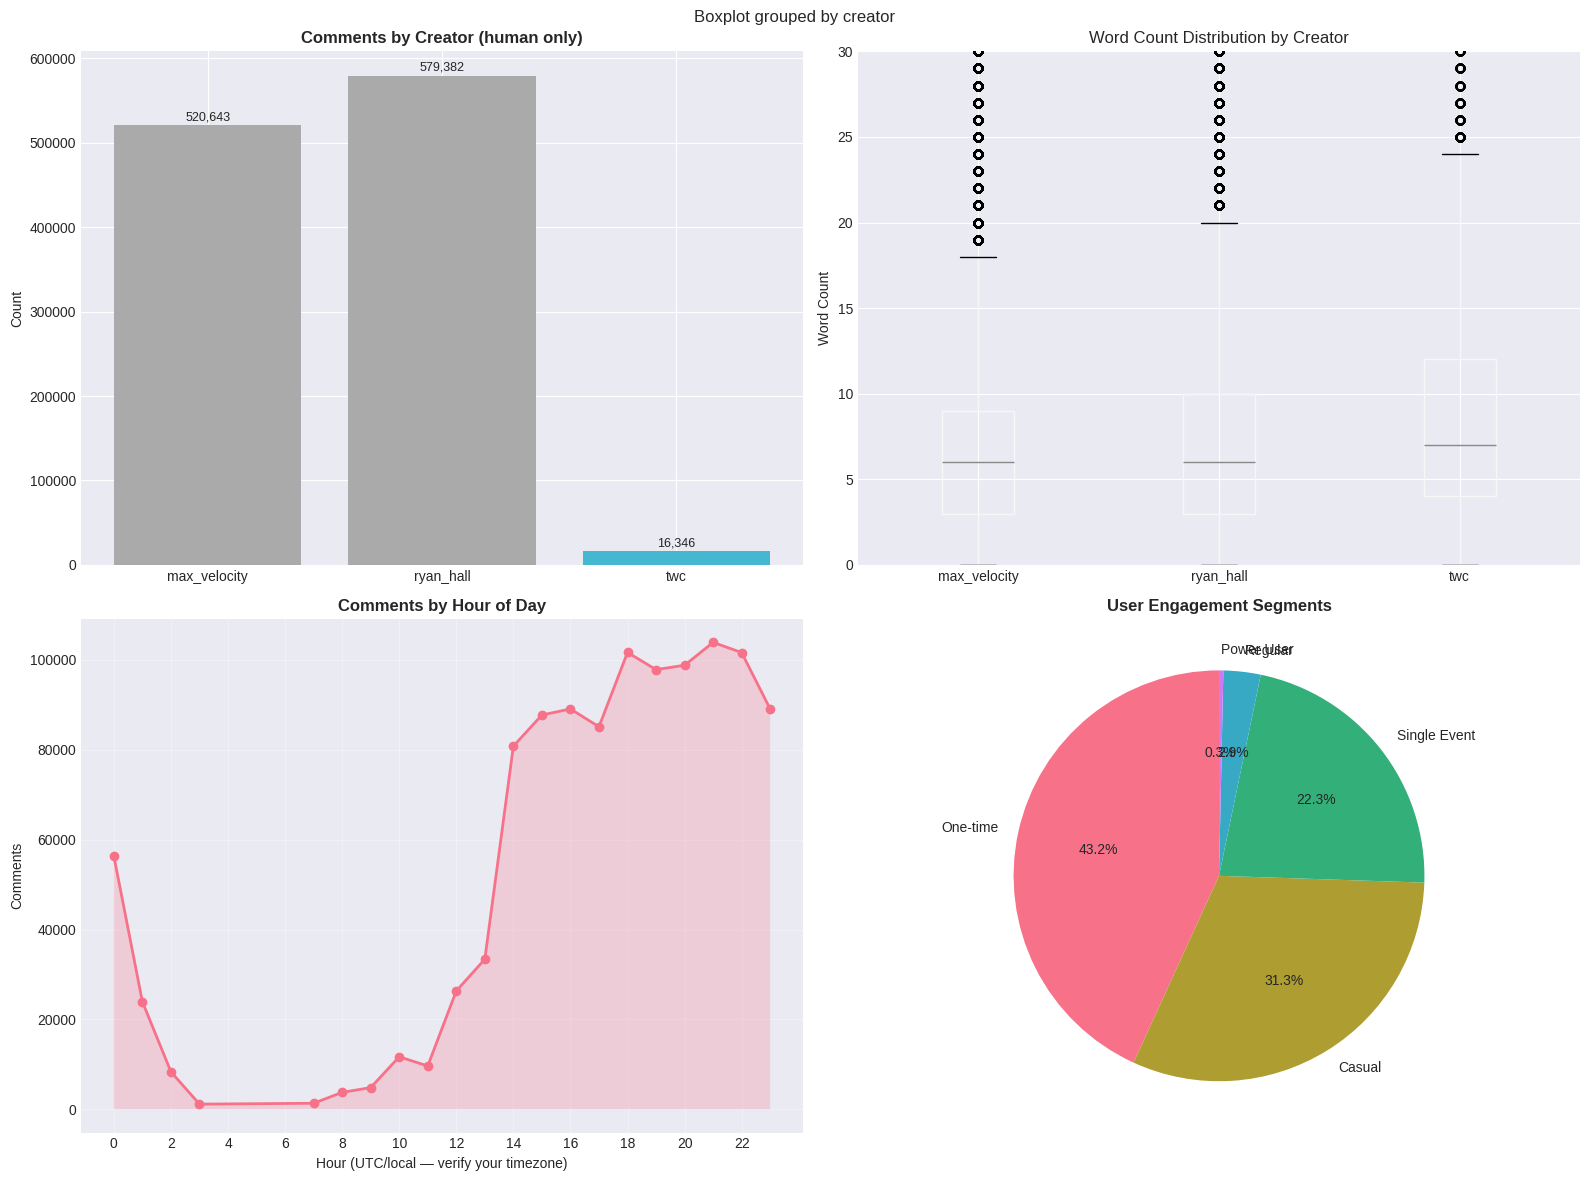

✓ Figure 1 saved


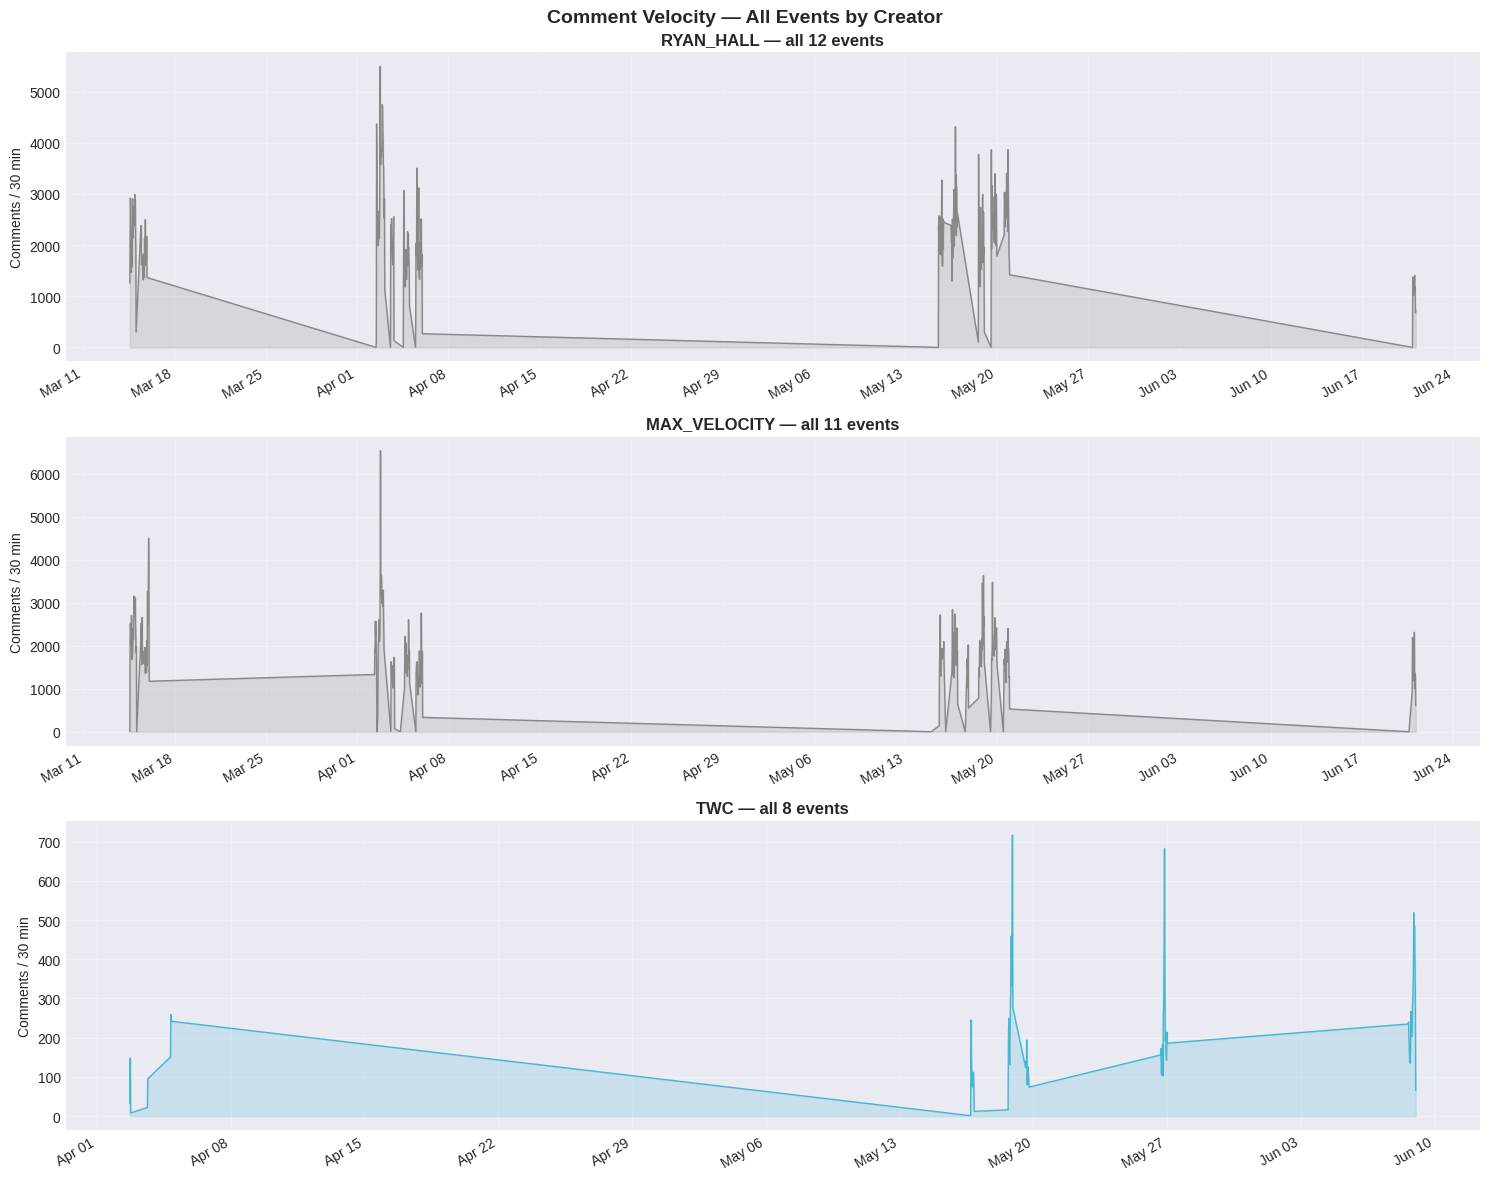

✓ Figure 2a saved


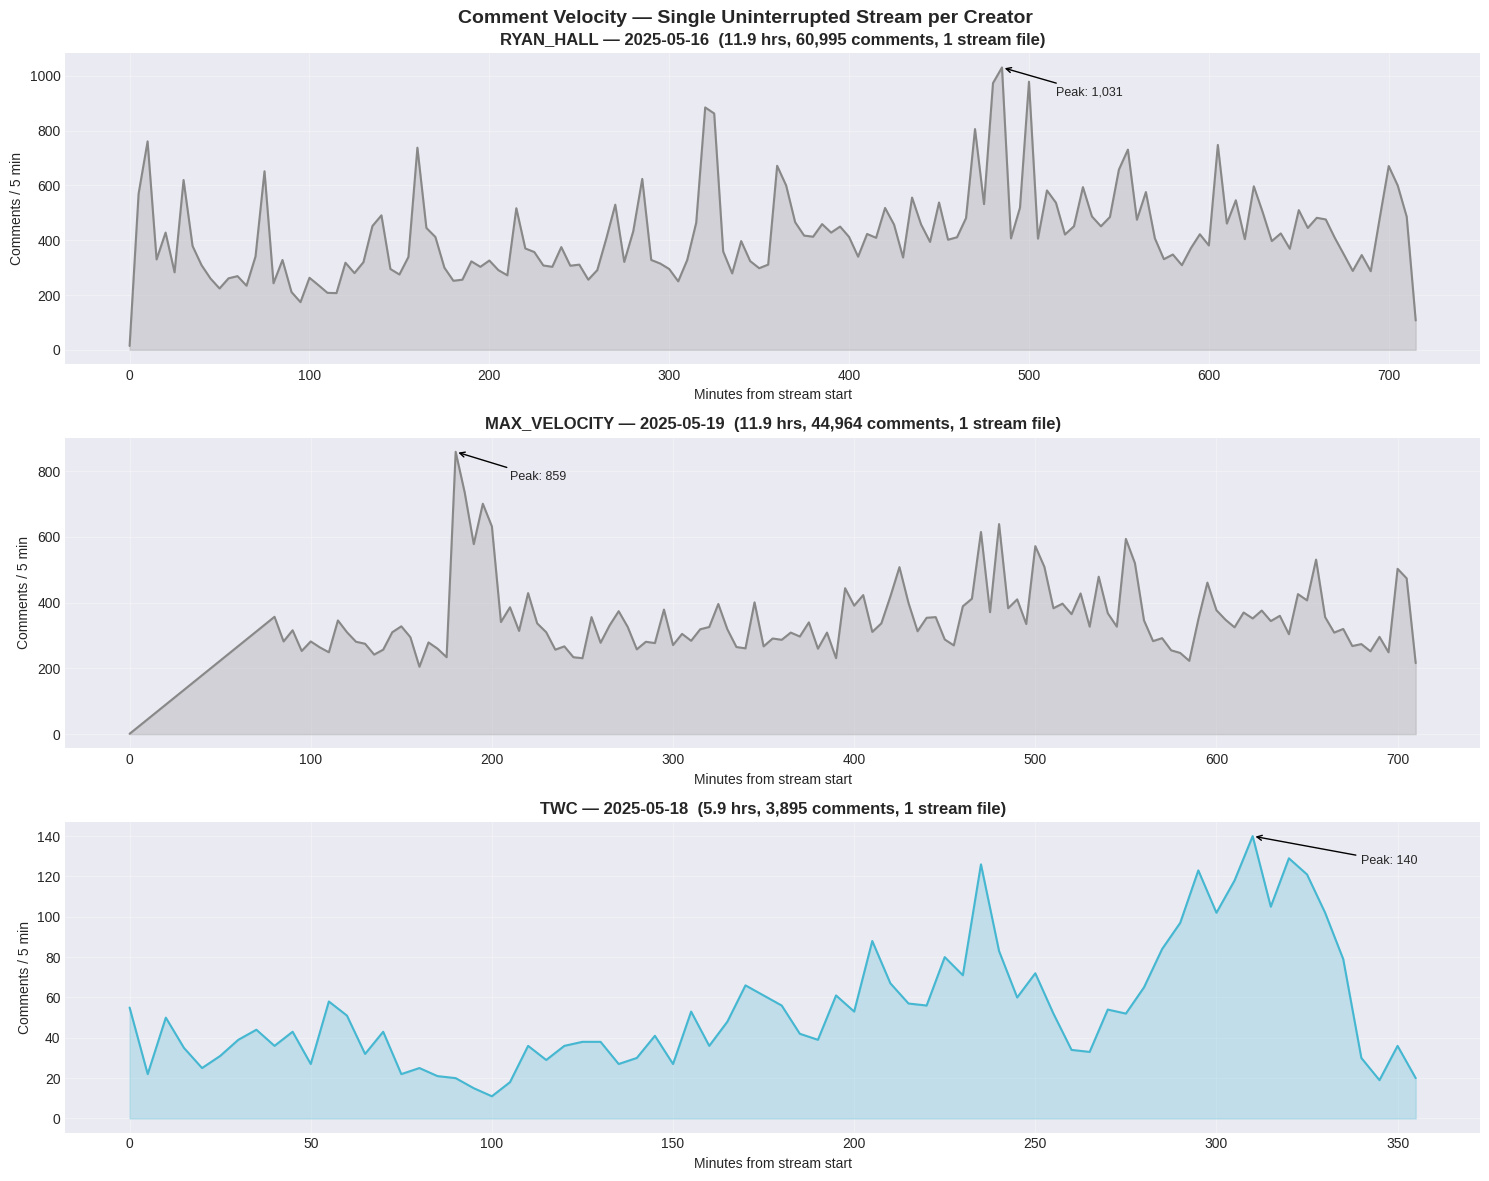

✓ Figure 2b saved


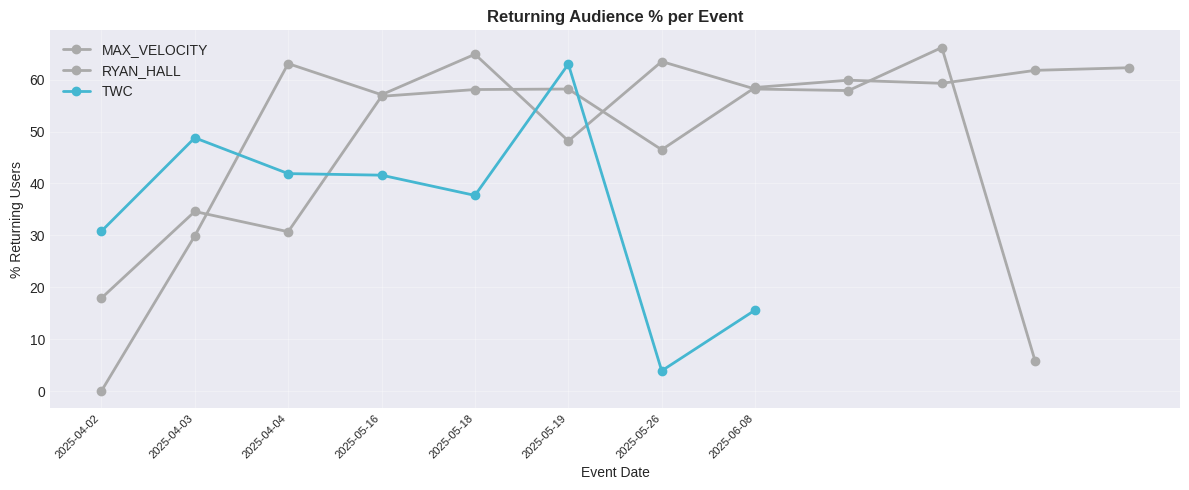

✓ Figure 3 saved


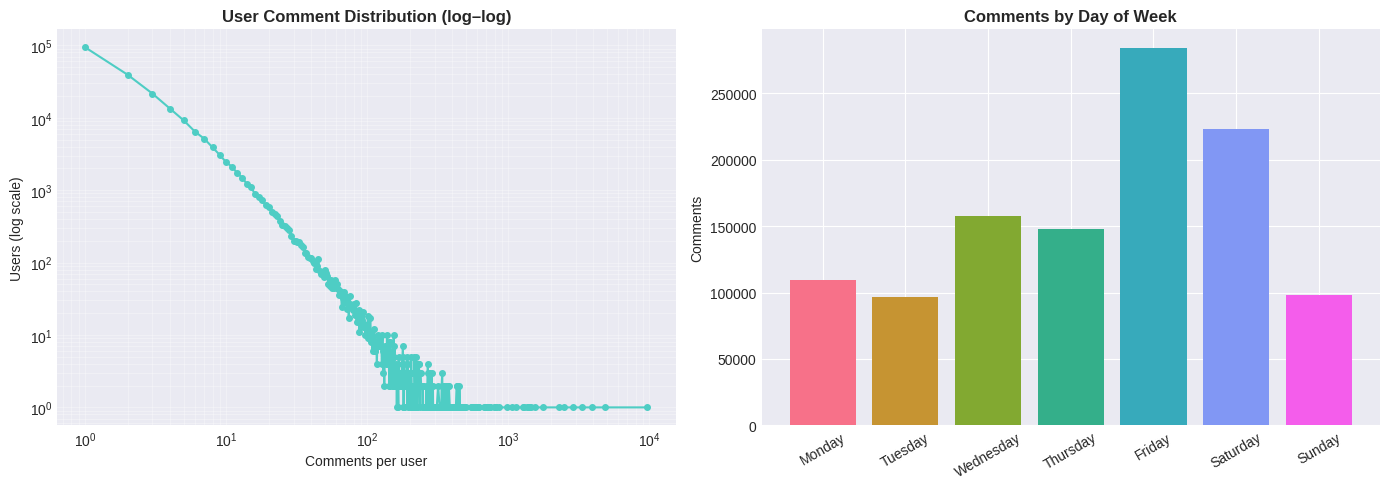

✓ Figure 4 saved


In [ ]:
# B8. Visualizations
# ─────────────────────────────────────────────────────────────────────────────

COLORS = {'ryan': '#4ECDC4', 'max': '#FF6B6B', 'twc': '#45B7D1'}
creator_colors = [COLORS.get(c, '#aaaaaa') for c in sorted(dfh['creator'].unique())]

# ── Figure 1: Dataset Overview ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Study 3 — Dataset Overview', fontsize=16, fontweight='bold', y=1.01)

# 1a: Total comments by creator
creator_counts = dfh['creator'].value_counts().sort_index()
bars = axes[0, 0].bar(creator_counts.index, creator_counts.values,
                       color=[COLORS.get(c, '#aaa') for c in creator_counts.index])
axes[0, 0].set_title('Comments by Creator (human only)', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for bar, v in zip(bars, creator_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + max(creator_counts)*0.01,
                    f'{v:,}', ha='center', fontsize=9)

# 1b: Word count distribution by creator
dfh.boxplot(column='word_count', by='creator', ax=axes[0, 1])
axes[0, 1].set_title('Word Count Distribution by Creator', fontweight='bold')
axes[0, 1].set_ylabel('Word Count')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylim(0, 30)
plt.sca(axes[0, 1])
plt.title('Word Count Distribution by Creator')

# 1c: Comments by hour
hourly_h = dfh.groupby('hour').size()
axes[1, 0].plot(hourly_h.index, hourly_h.values, marker='o', linewidth=2)
axes[1, 0].fill_between(hourly_h.index, hourly_h.values, alpha=0.25)
axes[1, 0].set_title('Comments by Hour of Day', fontweight='bold')
axes[1, 0].set_xlabel('Hour (UTC/local — verify your timezone)')
axes[1, 0].set_ylabel('Comments')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3)

# 1d: User segment pie
seg_counts = user_profiles['segment'].value_counts()
axes[1, 1].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
                startangle=90, colors=sns.color_palette('husl', len(seg_counts)))
axes[1, 1].set_title('User Engagement Segments', fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_FOLDER, 'fig1_overview.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved")


# ── Figure 2a: Aggregate velocity per creator (all events combined) ──────────
fig, axes_agg = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Comment Velocity — All Events by Creator', fontweight='bold', fontsize=14)

for ax, creator in zip(axes_agg, ['ryan_hall', 'max_velocity', 'twc']):
    subset = df[df['creator'] == creator].copy()
    # Bin by event-relative minutes but offset each event so they don't overlap
    # Instead: just show overall clock time binned to 30-min intervals
    subset['clock_bin'] = subset['comment_datetime'].dt.floor('30min')
    vel = subset.groupby('clock_bin').size()
    ax.plot(vel.index, vel.values, linewidth=1,
            color=COLORS.get(creator, '#888'))
    ax.fill_between(vel.index, vel.values, alpha=0.2,
                    color=COLORS.get(creator, '#888'))
    ax.set_title(f"{creator.upper()} — all {df[df['creator']==creator]['event_date'].nunique()} events",
                 fontweight='bold')
    ax.set_ylabel('Comments / 30 min')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator())
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_FOLDER, 'fig2a_velocity_aggregate.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2a saved")


# ── Figure 2b: Single clean stream per creator (no gaps) ─────────────────────
SHOWCASE_STREAMS = {
    'ryan_hall'    : pd.Timestamp('2025-05-16'),  # 61k comments, 12 hrs
    'max_velocity' : pd.Timestamp('2025-05-19'),  # 45k comments, 12 hrs
    'twc'          : pd.Timestamp('2025-05-18'),  # 3.9k comments, 6 hrs
}

fig, axes_single = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('Comment Velocity — Single Uninterrupted Stream per Creator',
             fontweight='bold', fontsize=14)

for ax, (creator, event_date) in zip(axes_single, SHOWCASE_STREAMS.items()):
    subset = df[
        (df['creator'] == creator) &
        (df['event_date'] == event_date)
    ].copy()

    duration_hrs = subset['time_from_event_start'].max() / 60
    n_comments = len(subset)

    subset['bin'] = (subset['time_from_event_start'] // 5).astype(int)
    vel = subset.groupby('bin').size()

    ax.plot(vel.index * 5, vel.values, linewidth=1.5,
            color=COLORS.get(creator, '#888'))
    ax.fill_between(vel.index * 5, vel.values, alpha=0.25,
                    color=COLORS.get(creator, '#888'))

    # Annotate peak
    pk_bin = vel.idxmax()
    ax.annotate(f"Peak: {vel.max():,}",
                xy=(pk_bin * 5, vel.max()),
                xytext=(pk_bin * 5 + 30, vel.max() * 0.9),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9)

    ax.set_title(f"{creator.upper()} — {event_date.date()}  "
                 f"({duration_hrs:.1f} hrs, {n_comments:,} comments, 1 stream file)",
                 fontweight='bold')
    ax.set_xlabel('Minutes from stream start')
    ax.set_ylabel('Comments / 5 min')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_FOLDER, 'fig2b_velocity_single_streams.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2b saved")



# ── Figure 3: Audience Retention ─────────────────────────────────────────────
fig, ax3 = plt.subplots(figsize=(12, 5))
for creator, grp in retention_df.groupby('creator'):
    grp = grp.sort_values('event_date')
    ax3.plot(range(len(grp)), grp['pct_returning'], marker='o',
              label=creator.upper(),
              color=COLORS.get(creator, '#aaa'),
              linewidth=2)
    ax3.set_xticks(range(len(grp)))
    ax3.set_xticklabels(
        [str(e.date()) for e in grp['event_date']],
        rotation=45, ha='right', fontsize=8
    )

ax3.set_title('Returning Audience % per Event', fontweight='bold')
ax3.set_ylabel('% Returning Users')
ax3.set_xlabel('Event Date')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_FOLDER, 'fig3_retention.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")


# ── Figure 4: Power-law user comment distribution ────────────────────────────
fig, axes4 = plt.subplots(1, 2, figsize=(14, 5))
comment_freq = user_comment_counts.value_counts().sort_index()
axes4[0].loglog(comment_freq.index, comment_freq.values, marker='o',
                 markersize=4, linewidth=1.5, color='#4ECDC4')
axes4[0].set_title('User Comment Distribution (log–log)', fontweight='bold')
axes4[0].set_xlabel('Comments per user')
axes4[0].set_ylabel('Users (log scale)')
axes4[0].grid(True, alpha=0.3, which='both')

# Comments per day of week
weekly_h = dfh.groupby('day_of_week').size().reindex(day_order)
axes4[1].bar(weekly_h.index, weekly_h.values, color=sns.color_palette('husl', 7))
axes4[1].set_title('Comments by Day of Week', fontweight='bold')
axes4[1].set_ylabel('Comments')
axes4[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_FOLDER, 'fig4_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved")

In [ ]:
# B9. Sampling Strategies for Manual Coding
# ─────────────────────────────────────────────────────────────────────────────
# Designed for trust-behavior coding per the Study 3 codebook.

RANDOM_SEED = 42

print("=" * 80)
print("SAMPLING STRATEGIES")
print("=" * 80)

# Exclude bots from all samples
dfh_sample = dfh.copy()

# ── Strategy 1: Simple random ────────────────────────────────────────────────
s1 = dfh_sample.sample(n=min(500, len(dfh_sample)), random_state=RANDOM_SEED)
print(f"\n1. Simple random (n={len(s1)}):")
print(s1['creator'].value_counts().to_string())

# ── Strategy 2: Stratified by creator × comment length ───────────────────────
N_PER_STRATUM = 60
s2 = dfh_sample.groupby(
    ['creator', 'length_category'], observed=True, group_keys=False
).apply(lambda x: x.sample(n=min(N_PER_STRATUM, len(x)), random_state=RANDOM_SEED))
print(f"\n2. Stratified creator × length (n={len(s2)}):")
print(pd.crosstab(s2['creator'], s2['length_category']))

# ── Strategy 3: Stratified by creator × event ────────────────────────────────
N_PER_EVENT = 30
s3 = dfh_sample.groupby(
    ['creator', 'event_date'], observed=True, group_keys=False
).apply(lambda x: x.sample(n=min(N_PER_EVENT, len(x)), random_state=RANDOM_SEED))
print(f"\n3. Stratified creator × event (n={len(s3)}):")
print(pd.crosstab(s3['creator'], s3['event_date'].dt.date))

# ── Strategy 4: Temporal windows (early / mid / late event) ──────────────────
def temporal_thirds_sample(df_event, n_per_third=20):
    max_t = df_event['time_from_event_start'].max()
    samples = []
    for label, lo, hi in [
        ('early',  0,          max_t * 0.33),
        ('middle', max_t*0.33, max_t * 0.67),
        ('late',   max_t*0.67, max_t),
    ]:
        window = df_event[
            (df_event['time_from_event_start'] >= lo) &
            (df_event['time_from_event_start'] < hi)
        ]
        s = window.sample(n=min(n_per_third, len(window)), random_state=RANDOM_SEED)
        s = s.copy()
        s['temporal_position'] = label
        samples.append(s)
    return pd.concat(samples)

s4_parts = []
for (creator, event_date), grp in dfh_sample.groupby(['creator', 'event_date'], observed=True):
    s4_parts.append(temporal_thirds_sample(grp, n_per_third=10))
s4 = pd.concat(s4_parts, ignore_index=True)
print(f"\n4. Temporal thirds sample (n={len(s4)}):")
print(pd.crosstab(s4['creator'], s4['temporal_position']))

# ── Strategy 5: User-segment stratified ──────────────────────────────────────
dfh_seg = dfh_sample.merge(user_profiles[['segment']], left_on='username_clean', right_index=True, how='left')
s5 = dfh_seg.groupby('segment', observed=True, group_keys=False).apply(
    lambda x: x.sample(n=min(100, len(x)), random_state=RANDOM_SEED)
)
print(f"\n5. User-segment stratified (n={len(s5)}):")
print(s5['segment'].value_counts().to_string())

# ── RECOMMENDED coding sample (strategy 2 + temporal flag) ───────────────────
print("\n" + "=" * 80)
print("RECOMMENDED CODING SAMPLE (Strategy 2 + temporal position)")
print("=" * 80)

coding_sample = s2.copy()
# Bring in segment from user_profiles
coding_sample = coding_sample.merge(
    user_profiles[['segment']],
    left_on='username_clean',
    right_index=True,
    how='left'
)
coding_sample['segment'] = coding_sample['segment'].fillna('Unknown')
# Add temporal position
def get_temporal_position(row, grp_maxes):
    max_t = grp_maxes.get((row['creator'], row['event_date']), 1)
    pct = row['time_from_event_start'] / max_t if max_t > 0 else 0
    if pct < 0.33:
        return 'early'
    elif pct < 0.67:
        return 'middle'
    return 'late'

grp_maxes = dfh.groupby(['creator', 'event_date'])['time_from_event_start'].max().to_dict()
coding_sample['temporal_position'] = coding_sample.apply(
    lambda r: get_temporal_position(r, grp_maxes), axis=1
)

# Add empty coding columns per Study 3 codebook
for col in ['L1_code', 'L2_code', 'notes']:
    coding_sample[col] = ''

coding_export = coding_sample[[
    'creator', 'event_date', 'comment_datetime', 'temporal_position',
    'username_clean', 'channel_url', 'comment_text', 'word_count',
    'length_category', 'segment',
    'L1_code', 'L2_code', 'notes'
]].copy()

out_coding = os.path.join(OUTPUT_FOLDER, 'coding_sample_recommended.csv')
coding_export.to_csv(out_coding, index=False)
print(f"\n✓ Coding sample saved: {out_coding}")
print(f"  n = {len(coding_export):,} comments")
print(f"  Distribution:")
print(pd.crosstab(coding_export['creator'], coding_export['length_category']))

SAMPLING STRATEGIES

1. Simple random (n=500):
creator
ryan_hall       286
max_velocity    205
twc               9

2. Stratified creator × length (n=720):
length_category  Very short (1w)  Short (2-5w)  Medium (6-15w)  Long (16+w)
creator                                                                    
max_velocity                  60            60              60           60
ryan_hall                     60            60              60           60
twc                           60            60              60           60

3. Stratified creator × event (n=930):
event_date    2025-03-14  2025-03-15  2025-04-02  2025-04-03  2025-04-04  \
creator                                                                    
max_velocity          30           0          30          30          30   
ryan_hall             30          30          30          30          30   
twc                    0           0          30          30          30   

event_date    2025-04-05  2025-05-14  2025-

In [ ]:
# B10. Export Results
# ─────────────────────────────────────────────────────────────────────────────

print("Exporting analysis artifacts...\n")

# 1. Creator comparison
creator_summary.to_csv(os.path.join(OUTPUT_FOLDER, 'analysis_creator_comparison.csv'))
print("✓ Creator comparison")

# 2. Event summary
event_summary.to_csv(os.path.join(OUTPUT_FOLDER, 'analysis_event_summary.csv'), index=False)
print("✓ Event summary")

# 3. User profiles
user_profiles.to_csv(os.path.join(OUTPUT_FOLDER, 'analysis_user_profiles.csv'))
print("✓ User profiles")

# 4. Audience retention
retention_df.to_csv(os.path.join(OUTPUT_FOLDER, 'analysis_audience_retention.csv'), index=False)
print("✓ Audience retention")

# 5. Top 100 users
top100 = pd.DataFrame({
    'username': user_comment_counts.head(100).index,
    'total_comments': user_comment_counts.head(100).values
}).merge(user_profiles, left_on='username', right_index=True, how='left')
top100.to_csv(os.path.join(OUTPUT_FOLDER, 'analysis_top100_users.csv'), index=False)
print("✓ Top 100 users")

# 6. Per-event velocity summary
vel_rows = []
for (creator, event_date), grp in dfh.groupby(['creator', 'event_date']):
    max_t = int(grp['time_from_event_start'].max())
    if max_t < 5:
        continue
    grp2 = grp.copy()
    grp2['bin'] = (grp2['time_from_event_start'] // 5).astype(int)
    vel = grp2.groupby('bin').size()
    vel_rows.append({
        'creator'          : creator,
        'event_date'       : event_date,
        'duration_min'     : max_t,
        'total_comments'   : len(grp),
        'peak_5min'        : int(vel.max()),
        'peak_at_minute'   : int(vel.idxmax() * 5),
        'avg_per_5min'     : round(vel.mean(), 1),
        'median_per_5min'  : round(vel.median(), 1),
    })
velocity_summary = pd.DataFrame(vel_rows)
velocity_summary.to_csv(os.path.join(OUTPUT_FOLDER, 'analysis_velocity_summary.csv'), index=False)
print("✓ Velocity summary")

print("\n" + "=" * 80)
print("ALL DONE")
print("=" * 80)
print(f"""
Output files in: {OUTPUT_FOLDER}

  stitched_chats.csv                — full stitched dataset
  coding_sample_recommended.csv     — stratified sample for manual coding
  analysis_creator_comparison.csv
  analysis_event_summary.csv
  analysis_user_profiles.csv
  analysis_audience_retention.csv
  analysis_top100_users.csv
  analysis_velocity_summary.csv
  fig1_overview.png
  fig2_velocity.png
  fig3_retention.png
  fig4_distribution.png

Suggested next analyses:
  - Keyword / pattern search to detect L1/L2 code candidates
  - Sentiment / certainty markers (VADER, linguistic features)
  - Question-detection classifier (messages ending in '?')
  - BERTopic / LDA for latent topic structure
  - Network analysis: @mention graphs for user–user interaction
""")

Exporting analysis artifacts...

✓ Creator comparison
✓ Event summary
✓ User profiles
✓ Audience retention
✓ Top 100 users
✓ Velocity summary

ALL DONE

Output files in: /content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/outputs

  stitched_chats.csv                — full stitched dataset
  coding_sample_recommended.csv     — stratified sample for manual coding
  analysis_creator_comparison.csv
  analysis_event_summary.csv
  analysis_user_profiles.csv
  analysis_audience_retention.csv
  analysis_top100_users.csv
  analysis_velocity_summary.csv
  fig1_overview.png
  fig2_velocity.png
  fig3_retention.png
  fig4_distribution.png

Suggested next analyses:
  - Keyword / pattern search to detect L1/L2 code candidates
  - Sentiment / certainty markers (VADER, linguistic features)
  - Question-detection classifier (messages ending in '?')
  - BERTopic / LDA for latent topic struc